In [1]:
import hydra
from omegaconf import OmegaConf
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

# Load the job model (grid, patch, extract stages) from the Hydra config package.
# Search provider and task builder are runtime plugins and are loaded separately.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel2",
)

search_cfg = OmegaConf.load("config/search/sentinel2_pc.yaml")
search_provider = hydra.utils.instantiate(search_cfg, _convert_="all", _partial_=True)

task_builder_cfg = OmegaConf.load("config/task_builder/grouped.yaml")
task_builder = hydra.utils.instantiate(
    task_builder_cfg, _convert_="all", _partial_=True
)

In [2]:
# Search
search_results = job.search(search_provider)
print(f"✓ Found {len(search_results)} scenes")

2026-06-25 20:06:37 [info     ] search_called                  provider=partial


✓ Found 16 scenes


In [3]:
# Build tasks
print("\n📦 Building tasks...")
tasks = job.build_tasks(search_results, task_builder)
print(f"✓ Built {len(tasks)} tasks")


📦 Building tasks...
2026-06-25 20:06:39 [info     ] build_tasks_start              assets=16 builder=partial


✓ Built 12 tasks


In [4]:
# Extract
print("\n⛏️ Extracting...")
artifacts = job.execute(tasks, executor=LocalExecutor(workers=8))
print(f"✓ Extracted {len(artifacts)} artifacts")


⛏️ Extracting...
2026-06-25 20:06:39 [info     ] execute_start                  executor=LocalExecutor task_count=12


/root/repos/aereo/.venv/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


✓ Extracted 54 artifacts


In [5]:
from aereo.viz import plot_artifact_patches

(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


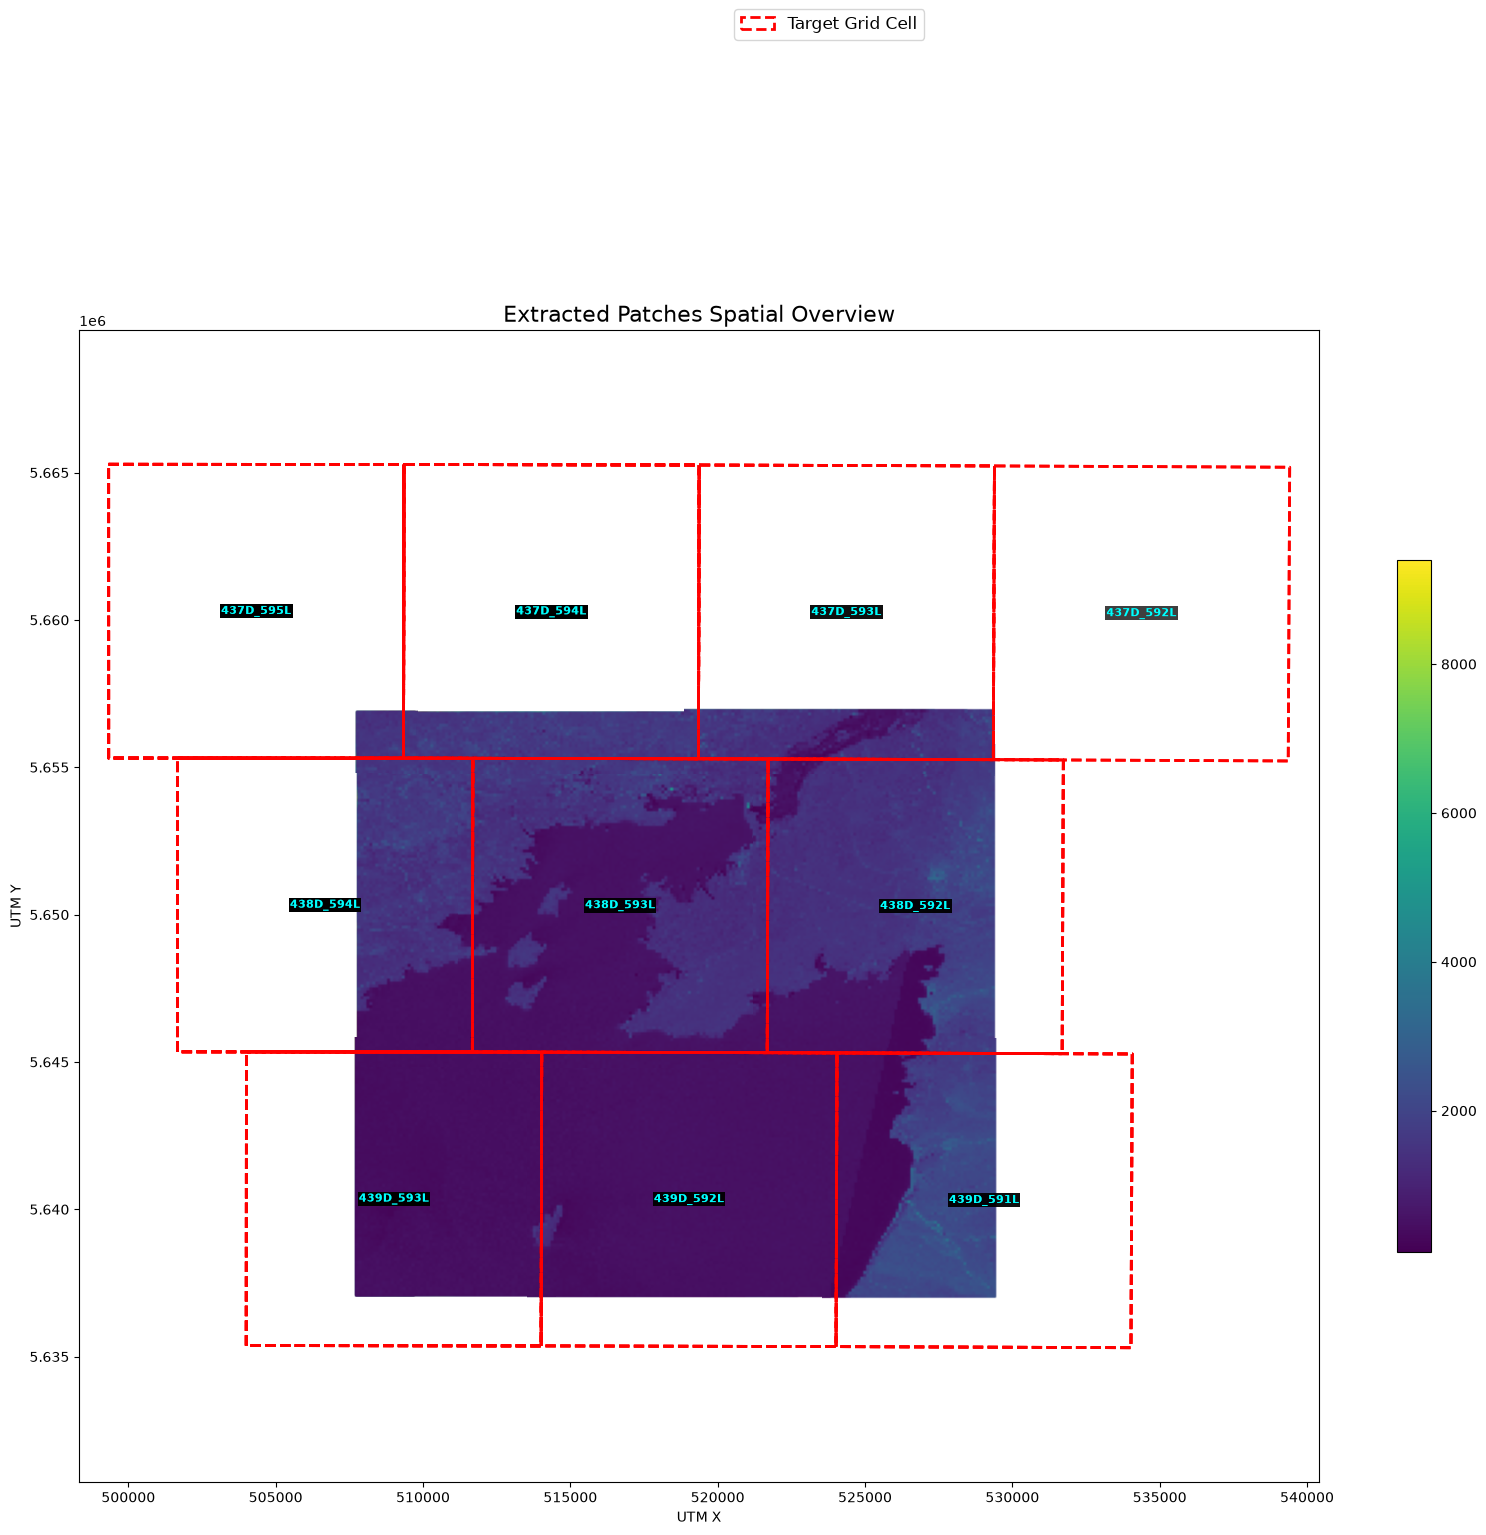

In [6]:
plot_artifact_patches(artifacts, ds_factor=10, cmap="viridis")